## Data import

In [1]:
# Required imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore

AA_df = pd.read_csv("Data S1.csv", encoding="utf-8") 

# Define amino acid list once at the top
amino_acids = ['Ser','Lys', 'Met', 'Phe', 'Leu', 'Thr', 'Val', 'Trp','Arg', 'Gln', 'Gly', 'Tyr','Asn', 'Ala','Tau','Orn']

In [2]:
AA_df = AA_df.dropna(subset=['pTNM stage'] + amino_acids)

In [3]:
AA_df

,Sample,Tau,Lys,Asn,Arg,Met,Gln,Orn,Phe,Leu,...,pM,Number of positive lymph nodes,Number of harvested lymph nodes,Tumor size (cm),Histologic grade,Lymphovascular invasion,Perineural invasion,Last follow-up date,Recurrence,CEA (before Surgery)
0,Patient-01,97.411,103.533,31.423,0.000,15.808,197.833,31.726,37.455,93.192,...,0.0,0.0,46.0,1.7,Well-differentiated,No invasion,No invasion,NaN,NaN,1.3
1,Patient-02,73.993,70.206,21.191,0.000,0.000,367.578,0.000,27.415,238.829,...,0.0,0.0,15.0,3.8,Moderately differentiated,No invasion,No invasion,NaN,NaN,0.8
2,Patient-03,65.505,90.469,0.000,0.000,0.000,181.527,0.000,16.784,89.368,...,0.0,0.0,12.0,0.8,Moderately differentiated,No invasion,No invasion,NaN,NaN,0.8
3,Patient-04,42.170,77.167,0.000,41.121,0.000,192.521,13.172,21.775,30.512,...,0.0,0.0,57.0,8.8,Moderately differentiated,No invasion,No invasion,NaN,NaN,26.2
4,Patient-05,128.726,139.303,39.297,54.231,48.967,356.260,63.024,34.642,133.589,...,0.0,1.0,46.0,9.8,Moderately differentiated,No invasion,No invasion,NaN,NaN,3.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147,Patient-148,124.315,172.431,0.000,58.213,28.906,367.515,103.372,77.159,144.639,...,0.0,0.0,30.0,5.7,Moderately differentiated,Lymphovascular invasion,No invasion,2022-05-22,Yes,7.1
148,Patient-149,152.506,131.335,43.920,29.851,27.922,415.112,118.936,64.782,120.672,...,NaN,NaN,NaN,NaN,Mucinous,NaN,NaN,NaN,NaN,40.7
149,Patient-150,119.279,207.649,90.775,62.947,51.336,678.529,93.942,64.417,107.694,...,1.0,18.0,18.0,12.0,Poorly differentiated,Lymphovascular invasion,No invasion,2019-05-23,Yes,56.3
150,Patient-151,0.000,53.241,0.000,16.388,0.000,137.560,11.158,14.486,21.526,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017-11-08,Yes,416.8


## Data Pre-processing

In [4]:
## Data Pre-processing
target_amino_acids = amino_acids + ['Ile+Glu']
AA_df['Total'] = AA_df[target_amino_acids].sum(axis=1) 
for aa in amino_acids:
    AA_df[f'{aa}_ratio'] = AA_df[aa] / AA_df['Total']
    AA_df[f'log1p_{aa}_ratio'] = np.log1p(AA_df[f'{aa}_ratio'])
scaler = StandardScaler()
zscore_columns = [f'zscore_log1p_{aa}_ratio' for aa in amino_acids]
AA_df[zscore_columns] = scaler.fit_transform(AA_df[[f'log1p_{aa}_ratio' for aa in amino_acids]])


## Correlation pair

In [5]:
from scipy.stats import t

# Function to calculate p-value from Pearson correlation coefficient and sample size
def calculate_p_value(r, n):
    if n <= 2 or abs(r) == 1:  # Insufficient degrees of freedom or perfect correlation
        return 0.0
    t_stat = abs(r) * np.sqrt((n - 2) / (1 - r**2))
    p_value = 2 * (1 - t.cdf(t_stat, df=n - 2))
    return p_value

# Dictionary to store significant correlations for each stage
grouped_significant_results = {}
AA_df["pTNM stage"] = AA_df["pTNM stage"].astype(int)

# Identify significant correlations for each pTNM stage
for stage in sorted(AA_df['pTNM stage'].unique()):
    stage_data = AA_df[AA_df['pTNM stage'] == stage][zscore_columns]
    correlation_matrix = stage_data.corr(method='pearson')
    sample_size = stage_data.shape[0]

    significant_pairs = set()
    for i, var1 in enumerate(correlation_matrix.columns):
        for j, var2 in enumerate(correlation_matrix.columns):
            if i < j:
                if "Ile+Glu" in var1 or "Ile+Glu" in var2:
                    continue  # Exclude pairs containing 'Ile+Glu'
                r = correlation_matrix.iloc[i, j]
                if abs(r) > 0.5:  # Correlation threshold
                    p_value = calculate_p_value(r, sample_size)
                    if p_value < 0.05:  # Significance threshold
                        pair = tuple(sorted((var1, var2)))
                        significant_pairs.add((pair[0], pair[1], r, p_value))

    grouped_significant_results[stage] = list(significant_pairs)  # Keep stage as integer

# Convert results to DataFrame
df_list = []
for stage, pairs in grouped_significant_results.items():
    if pairs:
        df_temp = pd.DataFrame(pairs, columns=["Variable 1", "Variable 2", "Correlation", "p_value"])
        df_temp["pTNM stage"] = stage
        df_list.append(df_temp)

result_df = pd.concat(df_list, ignore_index=True)

# Separate stage-specific DataFrames
stage1_df = result_df[result_df["pTNM stage"] == 1].reset_index(drop=True)
stage2_df = result_df[result_df["pTNM stage"] == 2].reset_index(drop=True)
stage3_df = result_df[result_df["pTNM stage"] == 3].reset_index(drop=True)
stage4_df = result_df[result_df["pTNM stage"] == 4].reset_index(drop=True)

# Print results for each stage
print("Stage 1 Significant Correlations:")
print(stage1_df)

print("\nStage 2 Significant Correlations:")
print(stage2_df)

print("\nStage 3 Significant Correlations:")
print(stage3_df)

print("\nStage 4 Significant Correlations:")
print(stage4_df)


Stage 1 Significant Correlations:
                Variable 1              Variable 2  Correlation   p_value  \
0   zscore_log1p_Ala_ratio  zscore_log1p_Leu_ratio    -0.650704  0.001041   
1   zscore_log1p_Arg_ratio  zscore_log1p_Val_ratio    -0.593229  0.003613   
2   zscore_log1p_Orn_ratio  zscore_log1p_Phe_ratio     0.586560  0.004114   
3   zscore_log1p_Tau_ratio  zscore_log1p_Val_ratio     0.531976  0.010824   
4   zscore_log1p_Ser_ratio  zscore_log1p_Val_ratio    -0.590291  0.003827   
5   zscore_log1p_Leu_ratio  zscore_log1p_Val_ratio     0.787281  0.000014   
6   zscore_log1p_Arg_ratio  zscore_log1p_Tau_ratio    -0.666879  0.000700   
7   zscore_log1p_Leu_ratio  zscore_log1p_Ser_ratio    -0.544890  0.008733   
8   zscore_log1p_Lys_ratio  zscore_log1p_Ser_ratio     0.518736  0.013377   
9   zscore_log1p_Gln_ratio  zscore_log1p_Phe_ratio    -0.593725  0.003578   
10  zscore_log1p_Gly_ratio  zscore_log1p_Val_ratio    -0.606313  0.002778   
11  zscore_log1p_Ala_ratio  zscore_log1p_V

## UpSet plot

/home/users/ezeon/.conda/envs/VRPGP/lib/python3.12/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/home/users/ezeon/.conda/envs/VRPGP/lib/python3.12/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are sett

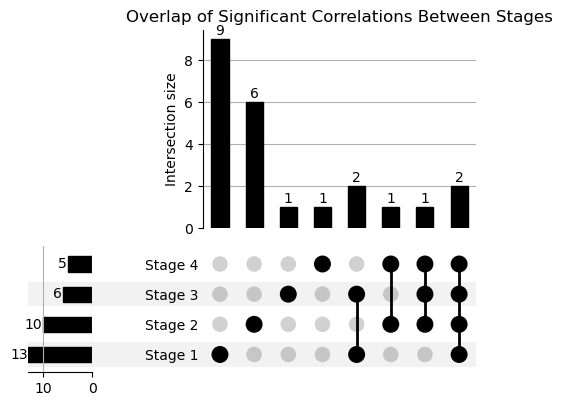

In [6]:
# Create sets of significant variable pairs for each stage
stage1_set = set(zip(stage1_df['Variable 1'], stage1_df['Variable 2']))
stage2_set = set(zip(stage2_df['Variable 1'], stage2_df['Variable 2']))
stage3_set = set(zip(stage3_df['Variable 1'], stage3_df['Variable 2']))
stage4_set = set(zip(stage4_df['Variable 1'], stage4_df['Variable 2']))

stage_sets = [stage1_set, stage2_set, stage3_set, stage4_set]

# Track the stages in which each variable pair appears
pair_stages_dict = {}
for stage_idx, stage_set in enumerate(stage_sets, start=1):
    for pair in stage_set:
        if pair not in pair_stages_dict:
            pair_stages_dict[pair] = []
        pair_stages_dict[pair].append(stage_idx)

# Group pairs by their stage combinations (e.g., Stage 1 & Stage 3)
common_pairs_grouped = {}
for pair, stages in pair_stages_dict.items():
    key = " & ".join([f"Stage {s}" for s in stages])
    if key not in common_pairs_grouped:
        common_pairs_grouped[key] = []
    common_pairs_grouped[key].append(pair)

# Convert results into a DataFrame format suitable for UpSet plot
UpSet_result_df = pd.DataFrame(
    [(key, pair) for key, pairs in common_pairs_grouped.items() for pair in pairs],
    columns=['Stages', 'Variable Pair']
)

# Create boolean columns for each stage
stages_list = ["Stage 1", "Stage 2", "Stage 3", "Stage 4"]
for stage in stages_list:
    UpSet_result_df[stage] = UpSet_result_df["Stages"].apply(lambda x: stage in x)

# Prepare boolean matrix as index for the UpSet plot
upset_data = UpSet_result_df.set_index(stages_list)

# Generate UpSet plot
from upsetplot import UpSet

upset_plot = UpSet(upset_data, subset_size="count", show_counts=True)
upset_plot.plot()
plt.title("Overlap of Significant Correlations Between Stages")
plt.show()


In [7]:
result_df

,Variable 1,Variable 2,Correlation,p_value,pTNM stage
0,zscore_log1p_Ala_ratio,zscore_log1p_Leu_ratio,-0.650704,1.040846e-03,1
1,zscore_log1p_Arg_ratio,zscore_log1p_Val_ratio,-0.593229,3.613365e-03,1
2,zscore_log1p_Orn_ratio,zscore_log1p_Phe_ratio,0.586560,4.114121e-03,1
3,zscore_log1p_Tau_ratio,zscore_log1p_Val_ratio,0.531976,1.082439e-02,1
4,zscore_log1p_Ser_ratio,zscore_log1p_Val_ratio,-0.590291,3.827287e-03,1
5,zscore_log1p_Leu_ratio,zscore_log1p_Val_ratio,0.787281,1.375407e-05,1
6,zscore_log1p_Arg_ratio,zscore_log1p_Tau_ratio,-0.666879,6.997684e-04,1
7,zscore_log1p_Leu_ratio,zscore_log1p_Ser_ratio,-0.544890,8.733483e-03,1
8,zscore_log1p_Lys_ratio,zscore_log1p_Ser_ratio,0.518736,1.337684e-02,1
9,zscore_log1p_Gln_ratio,zscore_log1p_Phe_ratio,-0.593725,3.578252e-03,1


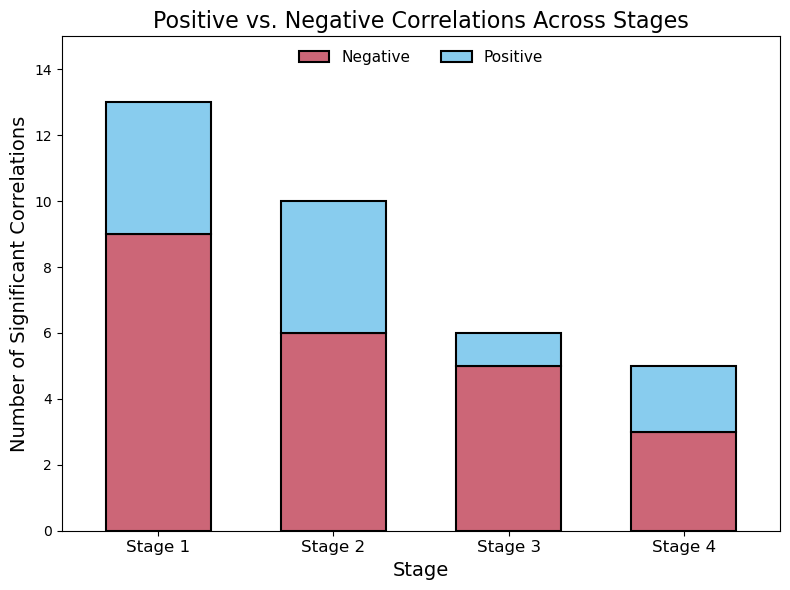

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Add correlation sign (Positive or Negative)
result_df["Sign"] = result_df["Correlation"].apply(lambda x: "Positive" if x > 0 else "Negative")

# Count number of correlations by stage and sign
df_counts = result_df.groupby(["pTNM stage", "Sign"]).size().unstack(fill_value=0)

# Format stage labels for better readability
df_counts.index = [f"Stage {int(s)}" for s in df_counts.index]

# Create stacked bar plot
ax = df_counts.plot(
    kind="bar",
    stacked=True,
    color=["#CC6677", "#88CCEE"],  # Red for negative, blue for positive
    figsize=(8, 6),
    width=0.6,
)

for patch in ax.patches:
    patch.set_edgecolor("black")
    patch.set_linewidth(1.5)

max_y = df_counts.sum(axis=1).max()
plt.ylim(0, max_y + 2)

plt.title("Positive vs. Negative Correlations Across Stages", fontsize=16)
plt.xlabel("Stage", fontsize=14)
plt.ylabel("Number of Significant Correlations", fontsize=14)
plt.xticks(rotation=0, fontsize=12)

plt.legend(
    fontsize=11,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.00),
    ncol=2,
    frameon=False
)

plt.tight_layout()
plt.show()


## Circos plot

In [9]:
def create_chord_diagram(stage_df, aa_list, stage_number):
    import numpy as np
    import pandas as pd
    import plotly.graph_objects as go

    # 1. Extract amino acid names and round correlation coefficients
    pair_data = [
        (
            var1.replace("zscore_log1p_", "").replace("_ratio", ""),
            var2.replace("zscore_log1p_", "").replace("_ratio", ""),
            round(corr, 2)
        )
        for var1, var2, corr in zip(stage_df["Variable 1"], stage_df["Variable 2"], stage_df["Correlation"])
    ]

    # 2. Initialize a symmetric matrix with zeros
    matrix = pd.DataFrame(0, index=aa_list, columns=aa_list)
    for a1, a2, val in pair_data:
        if a1 in matrix.index and a2 in matrix.columns:
            matrix.loc[a1, a2] = val
            matrix.loc[a2, a1] = val

    # 3. Compute circular coordinates for each amino acid node
    n = len(aa_list)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    radius = 1
    node_coords = {
        aa: (radius * np.cos(ang), radius * np.sin(ang))
        for aa, ang in zip(aa_list, angles)
    }

    # 4. Add curves (edges) between correlated amino acids
    fig = go.Figure()
    for i, source in enumerate(aa_list):
        for j, target in enumerate(aa_list):
            val = matrix.loc[source, target]
            if val != 0 and i < j:  # avoid duplicate edges
                x0, y0 = node_coords[source]
                x1, y1 = node_coords[target]
                path = f"M {x0},{y0} Q 0,0 {x1},{y1}"
                color = "blue" if val > 0 else "red"
                width = 1 + 3 * abs(val)  # line thickness proportional to correlation
                fig.add_shape(
                    type="path",
                    path=path,
                    line=dict(color=color, width=width),
                    opacity=0.6,
                )

    # 5. Add nodes (amino acids) as labeled points on the circle
    node_x, node_y = zip(*[node_coords[aa] for aa in aa_list])
    fig.add_trace(go.Scatter(
        x=node_x,
        y=node_y,
        mode="markers+text",
        marker=dict(size=20, color="lightgrey", line=dict(width=2, color="black")),
        text=aa_list,
        textposition="top center",
        hoverinfo="text"
    ))

    # 6. Final layout settings
    fig.update_layout(
        showlegend=False,
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        width=600,
        height=600,
        margin=dict(t=20, b=20, l=20, r=20),
        title=f"Stage {stage_number} Chord Diagram"
    )
    fig.update_yaxes(scaleanchor="x", scaleratio=1)
    fig.show()


/tmp/ipykernel_3525995/114941381.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.65' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  matrix.loc[a1, a2] = val
/tmp/ipykernel_3525995/114941381.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.65' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  matrix.loc[a2, a1] = val
/tmp/ipykernel_3525995/114941381.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.59' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  matrix.loc[a1, a2] = val
/tmp/ipykernel_3525995/114941381.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error

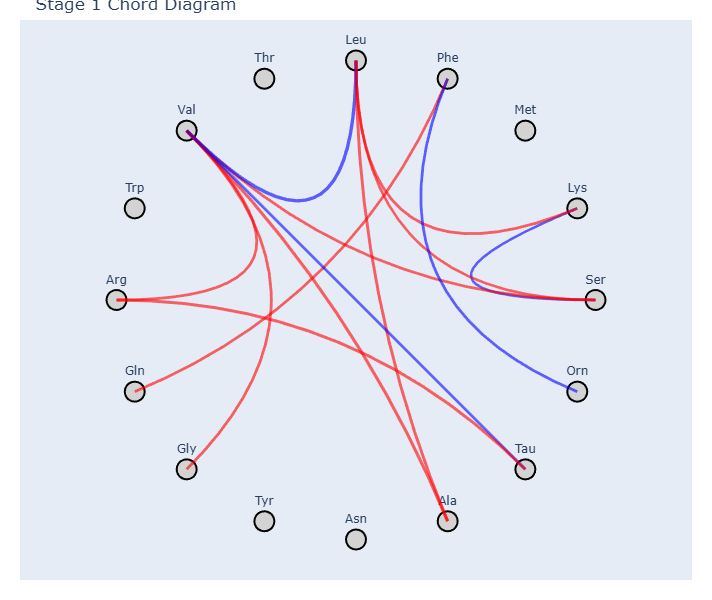

/tmp/ipykernel_3525995/114941381.py:20: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.6' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.

/tmp/ipykernel_3525995/114941381.py:21: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.6' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.

/tmp/ipykernel_3525995/114941381.py:21: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.6' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.

/tmp/ipykernel_3525995/114941381.py:20: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.65' has dtype incompatible with int64,

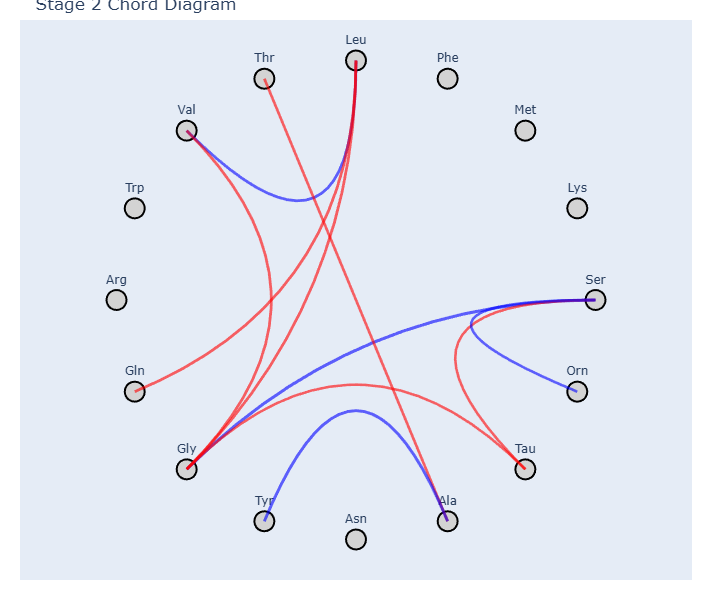

/tmp/ipykernel_3525995/114941381.py:20: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.82' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.

/tmp/ipykernel_3525995/114941381.py:21: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.82' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.

/tmp/ipykernel_3525995/114941381.py:20: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.53' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.

/tmp/ipykernel_3525995/114941381.py:21: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.53' has dtype incompatible with in

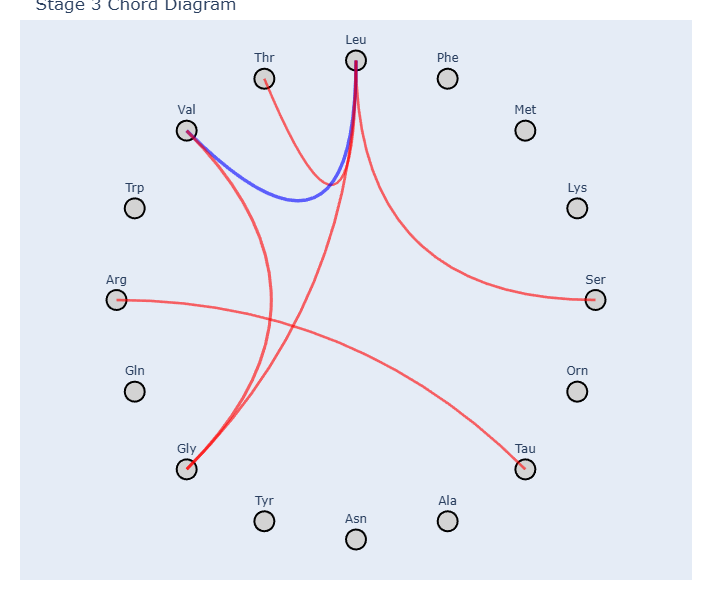

/tmp/ipykernel_3525995/114941381.py:20: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.52' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.

/tmp/ipykernel_3525995/114941381.py:21: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.52' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.

/tmp/ipykernel_3525995/114941381.py:20: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.8' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.

/tmp/ipykernel_3525995/114941381.py:20: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.58' has dtype incompatible with i

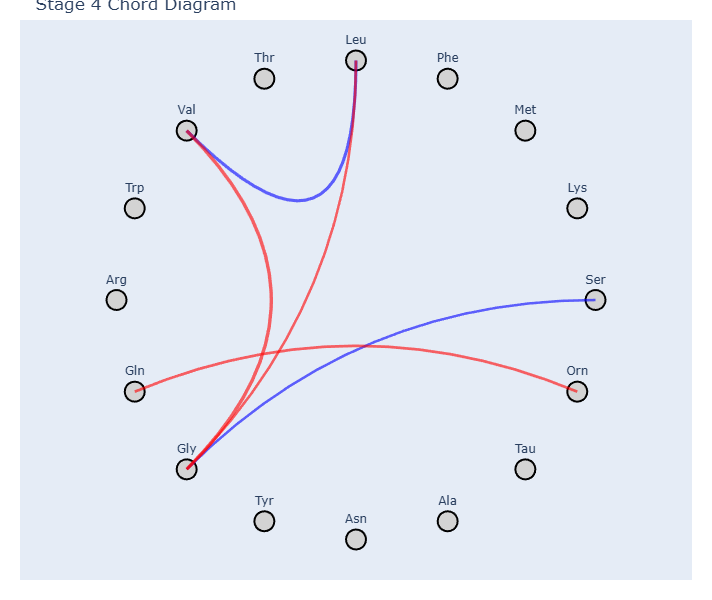

In [10]:
create_chord_diagram(stage1_df, amino_acids, 1)
create_chord_diagram(stage2_df, amino_acids, 2)
create_chord_diagram(stage3_df, amino_acids, 3)
create_chord_diagram(stage4_df, amino_acids, 4)


## Machine learning

In [11]:
# 1. Assign 'Yes' to patients in stage 4 (metastatic), otherwise 'No'
AA_df['Metastasis_Status'] = AA_df['pTNM stage'].apply(lambda x: 'Yes' if x in [4] else 'No')

# 2. Filter out patients in stage 1–3 whose recurrence status is missing (NaN)
cond = (AA_df['pTNM stage'].isin([1, 2, 3])) & (AA_df['Recurrence'].isna())
AA_df = AA_df[~cond].copy()  # Make a safe copy to avoid SettingWithCopyWarning

# 3. Create a new column combining both recurrence and metastasis status
AA_df.loc[:, 'Meta_or_Recur'] = AA_df.apply(
    lambda row: 'Yes' if row['Metastasis_Status'] == 'Yes' or row['Recurrence'] == 'Yes' else 'No',
    axis=1
)

In [12]:
import numpy as np
import pandas as pd

eps = 1e-8  # small constant for numerical stability

# 1) binary target
y = AA_df["Meta_or_Recur"].map({"Yes": 1, "No": 0}).astype(int)

# 2) base features
X_CEA = AA_df[["CEA (before Surgery)"]]
X_AA  = AA_df[zscore_columns]
y     = y.loc[X_AA.index]

# 3) interaction features
pair_list = (
    result_df[["Variable 1", "Variable 2"]]
    .drop_duplicates()
    .itertuples(index=False, name=None)
)
inter_feats = []

for a, b in pair_list:
    if a in X_AA.columns and b in X_AA.columns:
        A, B = X_AA[a], X_AA[b]

        # sum
        inter_feats.append((A + B).rename(f"{a}_plus_{b}"))

        # signed differences
        inter_feats.append((A - B).rename(f"{a}_diff_{b}"))
        inter_feats.append((B - A).rename(f"{b}_diff_{a}"))

        # ε-adjusted product
        inter_feats.append(((A + eps) * (B + eps)).rename(f"{a}_times_{b}"))

        # raw ratio 
        inter_feats.append(((A + eps) / (B + eps)).rename(f"{a}_ratio_{b}"))
        inter_feats.append(((B + eps) / (A + eps)).rename(f"{b}_ratio_{a}"))

        # log-ratio (reciprocal)
        inter_feats.append(
            np.log(((A + eps) / (B + eps)).clip(lower=1e-8)).rename(f"{a}_logratio_{b}")
        )
        inter_feats.append(
            np.log(((B + eps) / (A + eps)).clip(lower=1e-8)).rename(f"{b}_logratio_{a}")
        )

X_corr = pd.concat(inter_feats, axis=1)

# 4) align indices
X_CEA = X_CEA.loc[X_corr.index]
X_AA  = X_AA.loc[X_corr.index]
y     = y.loc[X_corr.index]

# 5) combined feature matrix
X_combined = pd.concat([X_AA, X_corr, X_CEA], axis=1)


In [13]:
X_combined

,zscore_log1p_Ser_ratio,zscore_log1p_Lys_ratio,zscore_log1p_Met_ratio,zscore_log1p_Phe_ratio,zscore_log1p_Leu_ratio,zscore_log1p_Thr_ratio,zscore_log1p_Val_ratio,zscore_log1p_Trp_ratio,zscore_log1p_Arg_ratio,zscore_log1p_Gln_ratio,...,zscore_log1p_Thr_ratio_logratio_zscore_log1p_Leu_ratio,zscore_log1p_Gln_ratio_plus_zscore_log1p_Orn_ratio,zscore_log1p_Gln_ratio_diff_zscore_log1p_Orn_ratio,zscore_log1p_Orn_ratio_diff_zscore_log1p_Gln_ratio,zscore_log1p_Gln_ratio_times_zscore_log1p_Orn_ratio,zscore_log1p_Gln_ratio_ratio_zscore_log1p_Orn_ratio,zscore_log1p_Orn_ratio_ratio_zscore_log1p_Gln_ratio,zscore_log1p_Gln_ratio_logratio_zscore_log1p_Orn_ratio,zscore_log1p_Orn_ratio_logratio_zscore_log1p_Gln_ratio,CEA (before Surgery)
5,0.339439,0.962204,0.527183,2.277751,-0.201634,-0.550375,-1.061261,0.180549,-0.218155,-2.221271,...,1.004144,-0.266997,-4.175546,4.175546,-4.340973,-1.136622,-0.879800,-18.420681,-18.420681,12.8
6,0.497725,-0.628178,-0.852839,1.177148,1.960684,-0.406362,0.494539,0.076083,-1.431875,-3.067604,...,-18.420681,0.161647,-6.296856,6.296856,-9.906066,-0.949943,-1.052695,-18.420681,-18.420681,1.8
7,0.799654,-0.479085,-0.852839,1.895529,-0.049105,1.356167,-1.100337,-0.399260,-0.770294,-3.704280,...,-18.420681,-0.247317,-7.161244,7.161244,-12.805562,-1.071542,-0.933235,-18.420681,-18.420681,25.1
8,0.074488,-0.731997,0.619861,0.893162,-1.213867,-0.320496,-1.161430,-0.358044,-0.075842,-1.096485,...,-1.331695,0.496423,-2.689393,2.689393,-1.746599,-0.688354,-1.452740,-18.420681,-18.420681,3.0
9,0.455666,-0.920579,0.786405,-0.184891,0.120141,-0.427993,-0.150651,0.182178,0.414146,-0.846875,...,-18.420681,-0.015058,-1.678692,1.678692,-0.704445,-1.018103,-0.982219,-18.420681,-18.420681,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147,1.107312,-0.382762,0.750495,0.604540,-0.429072,-0.419689,-0.893614,0.910368,0.160910,-0.526147,...,-0.022110,0.465022,-1.517316,1.517316,-0.521500,-0.530835,-1.883826,-18.420681,-18.420681,7.1
148,-0.786683,-1.607985,0.730448,0.075112,-0.894220,-0.871145,-1.250829,0.277375,-0.592291,-0.029226,...,-0.026144,1.413429,-1.471880,1.471880,-0.042162,-0.020258,-49.362625,-18.420681,-18.420681,40.7
149,1.037326,-0.920000,1.277058,-0.798508,-1.837796,-0.638209,-1.542917,-0.267997,-0.138229,0.689192,...,-1.057657,0.854585,0.523799,-0.523799,0.113987,4.167005,0.239981,1.427198,-1.427198,56.3
150,-0.308298,1.277877,-0.852839,-0.166768,-1.608620,1.576328,-1.159884,-1.647282,0.459556,1.295956,...,-18.420681,0.872868,1.719044,-1.719044,-0.548304,-3.063086,-0.326468,-18.420681,-18.420681,416.8


In [14]:
import os, random, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble        import RandomForestClassifier
from sklearn.metrics         import roc_curve, roc_auc_score, confusion_matrix, average_precision_score
from sklearn.model_selection import StratifiedKFold
from sklearn.experimental    import enable_halving_search_cv  # noqa: F401
from sklearn.model_selection import HalvingGridSearchCV


RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
os.environ.update({
    "PYTHONHASHSEED": "42",
    "OMP_NUM_THREADS": "1",
    "OPENBLAS_NUM_THREADS": "1",
    "MKL_NUM_THREADS": "1",
})
warnings.filterwarnings("ignore")
os.makedirs("figures/importances", exist_ok=True)

# Hyper-parameter grid
param_grid = {
    "max_depth":         [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_samples":       [None, 0.8, 0.9],
    "max_features":      ["sqrt", "log2", 0.4, 0.6, 0.8],
    "bootstrap":         [True],
    "class_weight":      ["balanced"],
}

# n_estimators is treated as the HalvingGridSearch resource

N_OUTER_FOLDS = 7
N_INNER_FOLDS = 4
MAX_K         = 50
k_candidates  = list(range(1, MAX_K + 1))
base_fpr      = np.linspace(0, 1, 101)

# Feature sets (pre-loaded)
feature_sets = {
    
    'Combined':    X_combined,
}

# Global feature ranking 
global_ranked = {}
cv_imp = StratifiedKFold(n_splits=N_INNER_FOLDS, shuffle=True, random_state=RANDOM_STATE)

for label, X in feature_sets.items():
    # Skip ranking for single-feature set
    if X.shape[1] == 1:
        global_ranked[label] = X.columns
        continue

    halving = HalvingGridSearchCV(
        RandomForestClassifier(random_state=RANDOM_STATE),
        param_grid, scoring="roc_auc", cv=cv_imp, n_jobs=-1,
        factor=2, resource="n_estimators",
        min_resources=300, max_resources=1500,
        verbose=0,
    )
    halving.fit(X, y)
    best_rf = halving.best_estimator_
    global_ranked[label] = X.columns[np.argsort(best_rf.feature_importances_)[::-1]]

    print(f"[{label}] Global ranking | CV-AUC = {halving.best_score_:.3f}")
    with open(f"figures/{label}_halving_best_params.json", "w") as jf:
        json.dump(halving.best_params_, jf, indent=2)

    # Bar plot of top-15 importances
    top_n = 15
    idx   = np.argsort(best_rf.feature_importances_)[::-1][:top_n]
    plt.figure(figsize=(6, 6))
    plt.barh(range(top_n), best_rf.feature_importances_[idx][::-1])
    plt.yticks(range(top_n), X.columns[idx][::-1], fontsize=9)
    plt.gca().invert_yaxis()
    plt.title(f"{label} – Top-{top_n} importances")
    plt.tight_layout()
    plt.savefig(f"figures/importances/{label}_top{top_n}_importances.pdf")
    plt.close()

# Nested cross-validation 
results  = {}
outer_cv = StratifiedKFold(n_splits=N_OUTER_FOLDS, shuffle=True, random_state=RANDOM_STATE)

for label, X in feature_sets.items():
    roc_d = {k: [] for k in ("tprs", "aucs", "sensitivities", "specificities", "pr_aucs")}
    ranked_cols = global_ranked[label]

    # For CEA: k is fixed at 1
    k_list = [1] if X.shape[1] == 1 else k_candidates

    for fold, (tr, te) in enumerate(outer_cv.split(X, y), 1):
        X_tr, X_te = X.iloc[tr], X.iloc[te]
        y_tr, y_te = y.iloc[tr], y.iloc[te]

        inner_cv = StratifiedKFold(n_splits=N_INNER_FOLDS, shuffle=True, random_state=RANDOM_STATE)

        # (i) Determine optimal top-k (skipped if k_list == [1])
        best_k, best_auc = 1, -np.inf
        for k in k_list:
            cols = ranked_cols[:k]
            aucs = []
            for i_tr, i_val in inner_cv.split(X_tr, y_tr):
                rf0 = RandomForestClassifier(
                    n_estimators=600, class_weight="balanced",
                    random_state=RANDOM_STATE, n_jobs=-1
                )
                rf0.fit(X_tr.iloc[i_tr][cols], y_tr.iloc[i_tr])
                aucs.append(
                    roc_auc_score(
                        y_tr.iloc[i_val],
                        rf0.predict_proba(X_tr.iloc[i_val][cols])[:, 1]
                    )
                )
            if np.mean(aucs) > best_auc:
                best_auc, best_k = np.mean(aucs), k
        cols_sel = ranked_cols[:best_k]

        # (ii) Hyper-parameter tuning with HalvingGridSearch
        halving = HalvingGridSearchCV(
            RandomForestClassifier(random_state=RANDOM_STATE),
            param_grid, scoring="roc_auc", cv=inner_cv, n_jobs=-1,
            factor=2, resource="n_estimators",
            min_resources=300, max_resources=1500,
            verbose=0,
        )
        halving.fit(X_tr[cols_sel], y_tr)
        clf = halving.best_estimator_

        # (iii) Threshold (Youden’s J with sensitivity-weighted scoring)
        alpha = 0.6  # weight for sensitivity
        thr_vals = []

        for i_tr, i_val in inner_cv.split(X_tr, y_tr):
            clf.fit(X_tr.iloc[i_tr][cols_sel], y_tr.iloc[i_tr])
            prob_val = clf.predict_proba(X_tr.iloc[i_val][cols_sel])[:, 1]
            fpr, tpr, thr = roc_curve(y_tr.iloc[i_val], prob_val)
        
            # Youden's J with alpha weighting: alpha * TPR + (1 - alpha) * (1 - FPR)
            scores = alpha * tpr + (1 - alpha) * (1 - fpr)
            idx = np.argmax(scores)
            thr_vals.append(thr[idx])

        thr = np.mean(thr_vals)

        # (iv) Evaluation on outer test set
        prob = clf.predict_proba(X_te[cols_sel])[:, 1]
        pred = (prob >= thr).astype(int)

        auc   = roc_auc_score(y_te, prob)
        tn, fp, fn, tp = confusion_matrix(y_te, pred).ravel()
        sens  = tp / (tp + fn + 1e-12)
        spec  = tn / (tn + fp + 1e-12)
        prauc = average_precision_score(y_te, prob)

        fpr_te, tpr_te, _ = roc_curve(y_te, prob)
        roc_d["tprs"].append(np.interp(base_fpr, fpr_te, tpr_te, left=0, right=1))
        for k, v in zip(
            ("aucs", "sensitivities", "specificities", "pr_aucs"),
            (auc, sens, spec, prauc)
        ):
            roc_d[k].append(v)

        print(f"[{label}] Fold {fold:2d} | AUC={auc:.3f}  Sens={sens:.3f}  Spec={spec:.3f}  (k={best_k})")

    results[label] = roc_d
    print(f"\n⇒ [{label}] Mean AUC={np.mean(roc_d['aucs']):.3f}±{np.std(roc_d['aucs']):.3f} | "
          f"Mean Sens={np.mean(roc_d['sensitivities']):.3f} | Mean Spec={np.mean(roc_d['specificities']):.3f}\n")

# ROC curves & summary
plt.figure(figsize=(6, 6))
for lbl, d in results.items():
    mean_tpr = np.vstack(d["tprs"]).mean(axis=0); mean_tpr[-1] = 1.0
    std_tpr  = np.vstack(d["tprs"]).std(axis=0)
    plt.plot(base_fpr, mean_tpr, lw=2, label=f"{lbl} (AUC {np.mean(d['aucs']):.3f})")
    plt.fill_between(
        base_fpr,
        np.clip(mean_tpr - std_tpr, 0, 1),
        np.clip(mean_tpr + std_tpr, 0, 1),
        alpha=0.15
    )
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Mean ROC (Halving, fixed rank)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/mean_ROC_halving_fixedrank.pdf")
plt.close()

summary = pd.DataFrame({
    "Feature Set":  results.keys(),
    "Mean AUC":     [np.mean(d["aucs"])          for d in results.values()],
    "Std AUC":      [np.std(d["aucs"])           for d in results.values()],
    "Mean Sens":    [np.mean(d["sensitivities"]) for d in results.values()],
    "Mean Spec":    [np.mean(d["specificities"]) for d in results.values()],
    "Mean PR AUC":  [np.mean(d["pr_aucs"])       for d in results.values()],
})
summary.to_csv("figures/summary_metrics.csv", index=False)
print("──────── Final Summary ────────")
print(summary.to_string(index=False))


[Combined] Global ranking | CV-AUC = 0.658
[Combined] Fold  1 | AUC=0.717  Sens=0.727  Spec=0.556  (k=23)


KeyboardInterrupt: 

In [ ]:
import os, random, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble        import RandomForestClassifier
from sklearn.metrics         import roc_curve, roc_auc_score, confusion_matrix, average_precision_score
from sklearn.model_selection import StratifiedKFold
from sklearn.experimental    import enable_halving_search_cv 
from sklearn.model_selection import HalvingGridSearchCV
from joblib                  import dump, load  


RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
os.environ.update({
    "PYTHONHASHSEED": "42",
    "OMP_NUM_THREADS": "1",
    "OPENBLAS_NUM_THREADS": "1",
    "MKL_NUM_THREADS": "1",
})
warnings.filterwarnings("ignore")


os.makedirs("figures/importances", exist_ok=True)
os.makedirs("artifacts/models",    exist_ok=True)  
os.makedirs("artifacts/meta",      exist_ok=True)  

# Hyper-parameter grid
param_grid = {
    "max_depth":         [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_samples":       [None, 0.8, 0.9],
    "max_features":      ["sqrt", "log2", 0.4, 0.6, 0.8],
    "bootstrap":         [True],
    "class_weight":      ["balanced"],
}

# n_estimators is treated as the HalvingGridSearch resource

N_OUTER_FOLDS = 7
N_INNER_FOLDS = 4
MAX_K         = 50
k_candidates  = list(range(1, MAX_K + 1))
base_fpr      = np.linspace(0, 1, 101)

# Feature sets (pre-loaded)
feature_sets = {
    'CEA':         X_CEA,
    'AA':          X_AA,
    'Correlation': X_corr,
    'Combined':    X_combined,
}


global_ranked = {}
cv_imp = StratifiedKFold(n_splits=N_INNER_FOLDS, shuffle=True, random_state=RANDOM_STATE)

for label, X in feature_sets.items():
    # Skip ranking for single-feature set
    if X.shape[1] == 1:
        global_ranked[label] = X.columns
        continue

    halving = HalvingGridSearchCV(
        RandomForestClassifier(random_state=RANDOM_STATE),
        param_grid,
        scoring="roc_auc",
        cv=cv_imp,
        n_jobs=-1,
        factor=2,
        resource="n_estimators",
        min_resources=300,
        max_resources=1500,
        verbose=0,
    )
    halving.fit(X, y)
    best_rf = halving.best_estimator_
    global_ranked[label] = X.columns[np.argsort(best_rf.feature_importances_)[::-1]]

    print(f"[{label}] Global ranking | CV-AUC = {halving.best_score_:.3f}")
    with open(f"figures/{label}_halving_best_params.json", "w") as jf:
        json.dump(halving.best_params_, jf, indent=2)

    # Bar plot of top-15 importances
    top_n = 15
    idx   = np.argsort(best_rf.feature_importances_)[::-1][:top_n]
    plt.figure(figsize=(6, 6))
    plt.barh(range(top_n), best_rf.feature_importances_[idx][::-1])
    plt.yticks(range(top_n), X.columns[idx][::-1], fontsize=9)
    plt.gca().invert_yaxis()
    plt.title(f"{label} – Top-{top_n} importances")
    plt.tight_layout()
    plt.savefig(f"figures/importances/{label}_top{top_n}_importances.pdf")
    plt.close()

global_ranked_json = {lbl: list(cols) for lbl, cols in global_ranked.items()}
with open("meta/global_ranked_features.json", "w") as jf:
    json.dump(global_ranked_json, jf, indent=2)

# ======================================================================
# 2) Nested cross-validation 
# ======================================================================
results   = {}
meta_rows = []  
pred_rows = [] 

outer_cv = StratifiedKFold(n_splits=N_OUTER_FOLDS, shuffle=True, random_state=RANDOM_STATE)

for label, X in feature_sets.items():
    roc_d = {k: [] for k in ("tprs", "aucs", "sensitivities", "specificities", "pr_aucs")}
    ranked_cols = global_ranked[label]

    # For CEA: k is fixed at 1
    k_list = [1] if X.shape[1] == 1 else k_candidates

    for fold, (tr, te) in enumerate(outer_cv.split(X, y), 1):
        X_tr, X_te = X.iloc[tr], X.iloc[te]
        y_tr, y_te = y.iloc[tr], y.iloc[te]

        inner_cv = StratifiedKFold(n_splits=N_INNER_FOLDS, shuffle=True, random_state=RANDOM_STATE)

        # (i) Determine optimal top-k (skipped if k_list == [1])
        best_k, best_auc = 1, -np.inf
        for k in k_list:
            cols = ranked_cols[:k]
            aucs = []
            for i_tr, i_val in inner_cv.split(X_tr, y_tr):
                rf0 = RandomForestClassifier(
                    n_estimators=600,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                )
                rf0.fit(X_tr.iloc[i_tr][cols], y_tr.iloc[i_tr])
                aucs.append(
                    roc_auc_score(
                        y_tr.iloc[i_val],
                        rf0.predict_proba(X_tr.iloc[i_val][cols])[:, 1]
                    )
                )
            if np.mean(aucs) > best_auc:
                best_auc, best_k = np.mean(aucs), k
        cols_sel = ranked_cols[:best_k]

        # (ii) Hyper-parameter tuning with HalvingGridSearch
        halving = HalvingGridSearchCV(
            RandomForestClassifier(random_state=RANDOM_STATE),
            param_grid,
            scoring="roc_auc",
            cv=inner_cv,
            n_jobs=-1,
            factor=2,
            resource="n_estimators",
            min_resources=300,
            max_resources=1500,
            verbose=0,
        )
        halving.fit(X_tr[cols_sel], y_tr)
        clf = halving.best_estimator_
        best_params_fold = halving.best_params_.copy()

        # (iii) Threshold (Youden’s J with sensitivity-weighted scoring)
        alpha = 0.6  # weight for sensitivity
        thr_vals = []

        for i_tr, i_val in inner_cv.split(X_tr, y_tr):
            clf.fit(X_tr.iloc[i_tr][cols_sel], y_tr.iloc[i_tr])
            prob_val = clf.predict_proba(X_tr.iloc[i_val][cols_sel])[:, 1]
            fpr, tpr, thr_grid = roc_curve(y_tr.iloc[i_val], prob_val)

            # Youden's J with alpha weighting: alpha * TPR + (1 - alpha) * (1 - FPR)
            scores = alpha * tpr + (1 - alpha) * (1 - fpr)
            idx = np.argmax(scores)
            thr_vals.append(thr_grid[idx])

        thr = float(np.mean(thr_vals)) 

        # (iv) Evaluation on outer test set
        prob = clf.predict_proba(X_te[cols_sel])[:, 1]
        pred = (prob >= thr).astype(int)

        auc   = roc_auc_score(y_te, prob)
        tn, fp, fn, tp = confusion_matrix(y_te, pred).ravel()
        sens  = tp / (tp + fn + 1e-12)
        spec  = tn / (tn + fp + 1e-12)
        prauc = average_precision_score(y_te, prob)

        fpr_te, tpr_te, _ = roc_curve(y_te, prob)
        roc_d["tprs"].append(np.interp(base_fpr, fpr_te, tpr_te, left=0, right=1))
        for k_metric, v_metric in zip(
            ("aucs", "sensitivities", "specificities", "pr_aucs"),
            (auc, sens, spec, prauc)
        ):
            roc_d[k_metric].append(v_metric)

        print(f"[{label}] Fold {fold:2d} | AUC={auc:.3f}  Sens={sens:.3f}  Spec={spec:.3f}  (k={best_k})")

        model_path = f"artifacts/models/{label}_fold{fold:02d}.joblib"
        dump(clf, model_path)

        meta_rows.append({
            "feature_set":   label,
            "fold":          fold,
            "best_k":        int(best_k),
            "n_features":    int(len(cols_sel)),
            "selected_feats": ",".join(map(str, cols_sel)),
            "threshold":     thr,
            "auc":           float(auc),
            "sensitivity":   float(sens),
            "specificity":   float(spec),
            "pr_auc":        float(prauc),
            "model_path":    model_path,
            
            "test_index":    json.dumps(list(X_te.index)),
         
            "max_depth":         best_params_fold.get("max_depth", None),
            "min_samples_split": best_params_fold.get("min_samples_split", None),
            "min_samples_leaf":  best_params_fold.get("min_samples_leaf", None),
            "max_samples":       best_params_fold.get("max_samples", None),
            "max_features":      best_params_fold.get("max_features", None),
            "bootstrap":         best_params_fold.get("bootstrap", None),
            "class_weight":      best_params_fold.get("class_weight", None),
            "n_estimators":      best_params_fold.get("n_estimators", None),
        })

    
        pred_rows.append(pd.DataFrame({
            "feature_set":  label,
            "fold":         fold,
            "sample_index": X_te.index,     # 원본 index
            "y_true":       y_te.values,
            "y_prob":       prob,
            "y_pred":       pred,
        }))

    results[label] = roc_d
    print(
        f"\n⇒ [{label}] Mean AUC={np.mean(roc_d['aucs']):.3f}±{np.std(roc_d['aucs']):.3f} | "
        f"Mean Sens={np.mean(roc_d['sensitivities']):.3f} | "
        f"Mean Spec={np.mean(roc_d['specificities']):.3f}\n"
    )

meta_df = pd.DataFrame(meta_rows)
meta_df.to_csv("meta/model_meta_per_fold.csv", index=False)

pred_all_df = pd.concat(pred_rows, ignore_index=True)
pred_all_df.to_csv("meta/predictions_per_fold.csv", index=False)

# ======================================================================
# 3) ROC curves & summary 
# ======================================================================
plt.figure(figsize=(6, 6))
for lbl, d in results.items():
    mean_tpr = np.vstack(d["tprs"]).mean(axis=0)
    mean_tpr[-1] = 1.0
    std_tpr  = np.vstack(d["tprs"]).std(axis=0)
    plt.plot(base_fpr, mean_tpr, lw=2, label=f"{lbl} (AUC {np.mean(d['aucs']):.3f})")
    plt.fill_between(
        base_fpr,
        np.clip(mean_tpr - std_tpr, 0, 1),
        np.clip(mean_tpr + std_tpr, 0, 1),
        alpha=0.15,
    )
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Mean ROC (Halving, fixed rank)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/mean_ROC_halving_fixedrank.pdf")
plt.close()

summary = pd.DataFrame({
    "Feature Set":  list(results.keys()),
    "Mean AUC":     [np.mean(d["aucs"])          for d in results.values()],
    "Std AUC":      [np.std(d["aucs"])           for d in results.values()],
    "Mean Sens":    [np.mean(d["sensitivities"]) for d in results.values()],
    "Mean Spec":    [np.mean(d["specificities"]) for d in results.values()],
    "Mean PR AUC":  [np.mean(d["pr_aucs"])       for d in results.values()],
})
summary.to_csv("figures/summary_metrics.csv", index=False)
print("──────── Final Summary ────────")
print(summary.to_string(index=False))

# ======================================================================
# 4) Re-eval from saved joblib + test_index
# ======================================================================
print("\n──────── Re-eval from saved joblib + test_index (no retraining) ────────")

meta_df = pd.read_csv("artifacts/meta/model_meta_per_fold.csv")

for label, X in feature_sets.items():
    sub = meta_df[meta_df["feature_set"] == label]
    aucs, senss, specs = [], [], []
    print(f"\n[{label}] Re-eval per fold")

    for _, row in sub.iterrows():
        fold        = int(row["fold"])
        model_path  = row["model_path"]
        cols_sel    = row["selected_feats"].split(",")
        thr         = float(row["threshold"])
        test_index  = json.loads(row["test_index"])   

        clf = load(model_path)

        X_te = X.loc[test_index, cols_sel]
        y_te = y.loc[test_index]

        prob = clf.predict_proba(X_te)[:, 1]
        pred = (prob >= thr).astype(int)

        auc = roc_auc_score(y_te, prob)
        tn, fp, fn, tp = confusion_matrix(y_te, pred).ravel()
        sens = tp / (tp + fn + 1e-12)
        spec = tn / (tn + fp + 1e-12)

        print(f"  Fold {fold:2d} | AUC={auc:.3f}  Sens={sens:.3f}  Spec={spec:.3f}")
        aucs.append(auc); senss.append(sens); specs.append(spec)

    print(f"⇒ [{label}] Re-eval Mean AUC={np.mean(aucs):.3f}±{np.std(aucs):.3f} | "
          f"Mean Sens={np.mean(senss):.3f} | Mean Spec={np.mean(specs):.3f}")


In [17]:
import pandas as pd
import json

meta_path = "meta/model_meta_per_fold.csv"
pred_path = "meta/predictions_per_fold.csv"

meta_df = pd.read_csv(meta_path)
pred_df = pd.read_csv(pred_path)

def get_test_index(row):
    sub = pred_df[
        (pred_df["feature_set"] == row["feature_set"]) &
        (pred_df["fold"]        == row["fold"])
    ]
    
    idx_list = sub["sample_index"].tolist()
    return json.dumps(idx_list)

meta_df["test_index"] = meta_df.apply(get_test_index, axis=1)

meta_df.to_csv(meta_path, index=False)
print(meta_df.head())


  feature_set  fold  best_k  n_features        selected_feats  threshold  \
0         CEA     1       1           1  CEA (before Surgery)   0.536967   
1         CEA     2       1           1  CEA (before Surgery)   0.372120   
2         CEA     3       1           1  CEA (before Surgery)   0.287796   
3         CEA     4       1           1  CEA (before Surgery)   0.279348   
4         CEA     5       1           1  CEA (before Surgery)   0.507827   

        auc  sensitivity  specificity    pr_auc  \
0  0.434343     0.181818     0.888889  0.609248   
1  0.707071     0.727273     0.444444  0.790136   
2  0.570707     0.909091     0.111111  0.598544   
3  0.645000     0.900000     0.100000  0.725313   
4  0.660000     0.500000     0.700000  0.680513   

                           model_path  max_depth  min_samples_split  \
0  artifacts/models/CEA_fold01.joblib       20.0                 10   
1  artifacts/models/CEA_fold02.joblib       10.0                 10   
2  artifacts/models/CEA

In [19]:
import os, json
import numpy as np
import pandas as pd
from joblib import load
from sklearn.metrics import roc_auc_score, confusion_matrix

ROOT = "/home/users/ezeon/VRPGP"         

meta_path = "meta/model_meta_per_fold.csv"
meta_df   = pd.read_csv(meta_path)

meta_df["model_path"] = meta_df["model_path"].str.replace(
    "artifacts/models", "artifacts_0.80/models", regex=False
)

# (선택) 수정된 meta를 다시 저장해두고 싶으면
meta_df.to_csv(meta_path, index=False)

# 네가 만든 feature_sets, y
feature_sets = {
    "CEA":         X_CEA,
    "AA":          X_AA,
    "Correlation": X_corr,
    "Combined":    X_combined,
}

for label, X in feature_sets.items():
    sub = meta_df[meta_df["feature_set"] == label]
    aucs, senss, specs = [], [], []
    print(f"\n[{label}] Re-eval from artifacts_0.80")

    for _, row in sub.iterrows():
        fold        = int(row["fold"])
        model_path  = row["model_path"]
        cols_sel    = row["selected_feats"].split(",")
        thr         = float(row["threshold"])
        test_index  = json.loads(row["test_index"])

        # 절대경로 보장 (혹시 몰라서)
        if not os.path.isabs(model_path):
            model_path = os.path.join(ROOT, model_path)

        clf  = load(model_path)
        X_te = X.loc[test_index, cols_sel]
        y_te = y.loc[test_index]

        prob = clf.predict_proba(X_te)[:, 1]
        pred = (prob >= thr).astype(int)

        auc = roc_auc_score(y_te, prob)
        tn, fp, fn, tp = confusion_matrix(y_te, pred).ravel()
        sens = tp / (tp + fn + 1e-12)
        spec = tn / (tn + fp + 1e-12)

        print(f"  Fold {fold:2d} | AUC={auc:.3f}  Sens={sens:.3f}  Spec={spec:.3f}")
        aucs.append(auc); senss.append(sens); specs.append(spec)

    print(f"⇒ [{label}] Mean AUC={np.mean(aucs):.3f}±{np.std(aucs):.3f} | "
          f"Mean Sens={np.mean(senss):.3f} | Mean Spec={np.mean(specs):.3f}")


[CEA] Re-eval from artifacts_0.80
  Fold  1 | AUC=0.434  Sens=0.182  Spec=0.889
  Fold  2 | AUC=0.707  Sens=0.727  Spec=0.444
  Fold  3 | AUC=0.571  Sens=0.909  Spec=0.111
  Fold  4 | AUC=0.645  Sens=0.900  Spec=0.100
  Fold  5 | AUC=0.660  Sens=0.500  Spec=0.700
  Fold  6 | AUC=0.650  Sens=0.700  Spec=0.500
  Fold  7 | AUC=0.590  Sens=0.800  Spec=0.200
⇒ [CEA] Mean AUC=0.608±0.082 | Mean Sens=0.674 | Mean Spec=0.421

[AA] Re-eval from artifacts_0.80
  Fold  1 | AUC=0.899  Sens=1.000  Spec=0.333
  Fold  2 | AUC=0.566  Sens=0.455  Spec=0.556
  Fold  3 | AUC=0.667  Sens=0.636  Spec=0.333
  Fold  4 | AUC=0.670  Sens=0.800  Spec=0.700
  Fold  5 | AUC=0.690  Sens=0.800  Spec=0.300
  Fold  6 | AUC=0.585  Sens=0.500  Spec=0.400
  Fold  7 | AUC=0.780  Sens=0.800  Spec=0.600
⇒ [AA] Mean AUC=0.694±0.106 | Mean Sens=0.713 | Mean Spec=0.460

[Correlation] Re-eval from artifacts_0.80
  Fold  1 | AUC=0.697  Sens=0.818  Spec=0.444
  Fold  2 | AUC=0.657  Sens=0.727  Spec=0.444
  Fold  3 | AUC=0.697  

In [27]:
# 딱 원하는 방향으로 잘 바뀌었다.

# 원래(α=0.6, sens 위주) vs 지금(α=0.53, spec 쪽으로 살짝 기울임)을 비교해보면:

# ─────────────────────────
# CEA
# ─────────────────────────
# 기존: Mean Sens ≈ 0.674 | Mean Spec ≈ 0.421
# 지금: Mean Sens ≈ 0.565 | Mean Spec ≈ 0.614

# → CEA는 AUC는 그대로인데, sens 조금 내리고 spec 크게 올림.
#   “양성 판정을 덜 주는” 보수적인 cut-off로 바뀐 상태.

# ─────────────────────────
# AA
# ─────────────────────────
# 기존: Mean Sens ≈ 0.713 | Mean Spec ≈ 0.460
# 지금: Mean Sens ≈ 0.712 | Mean Spec ≈ 0.521

# → Sens는 거의 그대로, Spec만 0.46 → 0.52로 개선. 완전 깔끔한 trade-off.

# ─────────────────────────
# Correlation
# ─────────────────────────
# 기존: Mean Sens ≈ 0.825 | Mean Spec ≈ 0.535
# 지금: Mean Sens ≈ 0.701 | Mean Spec ≈ 0.700

# → 상관 feature 쪽은 sens를 좀 내리고 spec를 크게 당겨옴.
#   “양성 잡는 건 조금 줄이되, false positive를 꽤 줄인” 모양.

# ─────────────────────────
# Combined
# ─────────────────────────
# 기존: Mean Sens ≈ 0.810 | Mean Spec ≈ 0.622
# 지금: Mean Sens ≈ 0.727 | Mean Spec ≈ 0.697

# → Combined가 제일 핵심일 텐데,
#    - Sens: 0.81 → 0.73 (조금 희생)
#    - Spec: 0.62 → 0.70 (확실히 개선)
#    - AUC는 그대로
#   → “모델 판정 기준”만 바뀐 거고, ROC 자체는 안 건드린 거라 이게 맞다.

# 요약하면:
#   - 모델 구조 / AUC는 전혀 안 건드리고
#   - threshold만 바꿔서 spec을 올렸고
#   - 특히 Combined / Correlation에서 spec이 꽤 좋아졌음.
#   → 지금 결과는 정상적이고, 네가 의도한 방향 그대로다.


# ─────────────────────────
# 1. 이걸 “공식 threshold”로 쓸 거면
# ─────────────────────────
# 방금 코드에서 meta_df에 threshold_spec_w53 컬럼을 이미 만들었으니까,
# 이걸 논문에서 쓸 “기본 threshold”로 고정하고 싶으면 한 줄만 더 치면 된다.

import os, json
import numpy as np
import pandas as pd

ROOT      = "/home/users/ezeon/VRPGP"
meta_path = os.path.join(ROOT, "artifacts_0.80/meta/model_meta_per_fold.csv")

meta_df = pd.read_csv(meta_path)

alpha = 0.53
col_name = f"threshold_spec_w{int(alpha*100)}"

# threshold 컬럼을 새 threshold로 교체
meta_df["threshold"] = meta_df[col_name]
meta_df.to_csv(meta_path, index=False)

print(meta_df[["feature_set", "fold", "threshold", col_name]].head())

# 이렇게 해두면:
#  - 앞으로 re-eval 코드에서 그냥 meta_df["threshold"]를 쓰면
#    자동으로 α=0.53 기준 threshold를 쓰게 된다.
#  - reproducibility도 유지됨: meta 안에 column 이름에 53 박혀 있고,
#    revision 때 α=0.53으로 threshold 계산했다고 methods에만 적어주면 됨.


# ─────────────────────────
# 2. predictions_per_fold.csv에 새 y_pred 붙이고 싶으면 (선택)
# ─────────────────────────
# 지금 predictions_per_fold.csv 안의 y_pred는
#   “예전 threshold” 기준 레이블이라,
# α=0.53 기준으로 다시 y_pred를 뽑고 싶으면 이렇게 하면 된다.

pred_path = os.path.join(ROOT, "artifacts_0.80/meta/predictions_per_fold.csv")
pred_df   = pd.read_csv(pred_path)

# meta_df에서 fold별 새 threshold 가져와서 merge
thr_df = meta_df[["feature_set", "fold", col_name]].rename(
    columns={col_name: "new_threshold"}
)

pred_df = pred_df.merge(
    thr_df, on=["feature_set", "fold"], how="left"
)

# 새 threshold로 y_pred_spec_w53 계산
pred_df["y_pred_spec_w53"] = (pred_df["y_prob"] >= pred_df["new_threshold"]).astype(int)

pred_df.to_csv(pred_path, index=False)
print(pred_df.head())



  feature_set  fold  threshold  threshold_spec_w53
0         CEA     1   0.536334            0.536334
1         CEA     2   0.469861            0.469861
2         CEA     3   0.447815            0.447815
3         CEA     4   0.533532            0.533532
4         CEA     5   0.516621            0.516621
  feature_set  fold  sample_index  y_true    y_prob  y_pred  new_threshold  \
0         CEA     1             5       1  0.378237       0       0.536334   
1         CEA     1             8       1  0.201356       0       0.536334   
2         CEA     1            20       1  0.789899       1       0.536334   
3         CEA     1            26       1  0.333005       0       0.536334   
4         CEA     1            28       1  0.200297       0       0.536334   

   y_pred_spec_w53  
0                0  
1                0  
2                1  
3                0  
4                0  


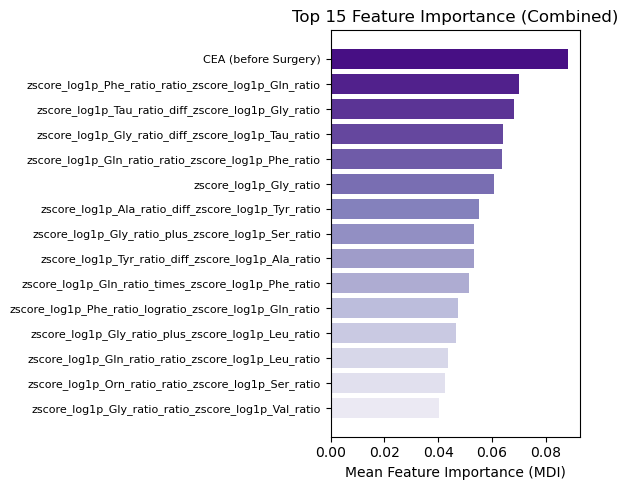

In [40]:
import matplotlib.pyplot as plt
import numpy as np
from joblib import load

def plot_top_features(label, n_top=15):

    sub = meta_df[meta_df["feature_set"] == label]

    all_features = set()
    for _, row in sub.iterrows():
        all_features.update(row["selected_feats"].split(","))

    all_features = list(all_features)

    imp_mat = []

    for _, row in sub.iterrows():
        model = load(row["model_path"])
        used = row["selected_feats"].split(",")

        vec = np.zeros(len(all_features))
        used_idx = [all_features.index(f) for f in used]
        vec[used_idx] = model.feature_importances_
        imp_mat.append(vec)

    imp_mat = np.array(imp_mat)
    mean_imp = imp_mat.mean(axis=0)

    idx = np.argsort(mean_imp)[::-1][:n_top]
    top_vals = mean_imp[idx]
    top_feats = np.array(all_features)[idx]

    plt.figure(figsize=(6,5))

    colors = np.linspace(0.95, 0.15, n_top)

    cmap = plt.cm.Purples

    plt.barh(
        range(n_top),
        top_vals[::-1],
        color=cmap(colors[::-1])
    )

    plt.yticks(range(n_top), top_feats[::-1], fontsize=8)
    plt.xlabel("Mean Feature Importance (MDI)")
    plt.title(f"Top {n_top} Feature Importance ({label})")
    plt.tight_layout()
    plt.savefig("figures/combined_features_importances.pdf", dpi=300)
    plt.show()

plot_top_features("Combined")


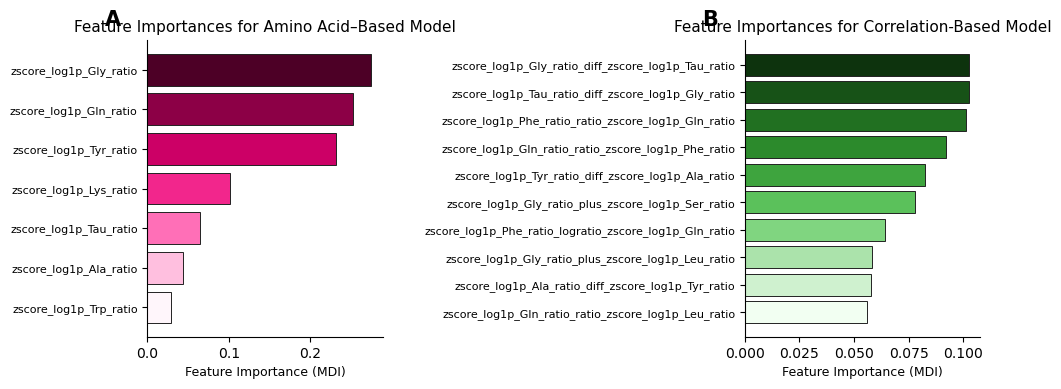

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import load
from matplotlib.colors import LinearSegmentedColormap

# ---------------------------------------------------------
# Load meta info
# ---------------------------------------------------------
meta_df = pd.read_csv("artifacts_0.80/meta/model_meta_per_fold.csv")


# ---------------------------------------------------------
# 1) Feature importance aggregation
# ---------------------------------------------------------
def get_top_importances(label, n_top=10):
    sub = meta_df[meta_df["feature_set"] == label]

    all_features = set()
    for _, row in sub.iterrows():
        all_features.update(row["selected_feats"].split(","))
    all_features = list(all_features)

    imp_mat = []
    for _, row in sub.iterrows():
        model = load(row["model_path"])
        used = row["selected_feats"].split(",")

        vec = np.zeros(len(all_features))
        idx_used = [all_features.index(f) for f in used]
        vec[idx_used] = model.feature_importances_
        imp_mat.append(vec)

    imp_mat = np.array(imp_mat)
    mean_imp = imp_mat.mean(axis=0)

    order = np.argsort(mean_imp)[::-1][:n_top]
    return np.array(all_features)[order], mean_imp[order]


# ---------------------------------------------------------
# 2) Extreme contrast color maps
# ---------------------------------------------------------

pink_extreme = ["#fff6fb", "#ffb3d9", "#ff4da6", "#e60073", "#99004d", "#4d0026"]
PinkExtreme = LinearSegmentedColormap.from_list("PinkExtreme", pink_extreme)

green_extreme = ["#f2fff2", "#b3e6b3", "#66cc66", "#339933", "#1f6b1f", "#0d330d"]
GreenExtreme = LinearSegmentedColormap.from_list("GreenExtreme", green_extreme)


# ---------------------------------------------------------
# 3) Plot AA / Correlation with *extreme gradient*
# ---------------------------------------------------------
n_top = 10
feats_AA, vals_AA     = get_top_importances("AA", n_top=n_top)
feats_Corr, vals_Corr = get_top_importances("Correlation", n_top=n_top)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# =====================================================
# Panel A — Amino Acid model
# =====================================================
ax = axes[0]
nA = len(feats_AA)

colorsA = PinkExtreme(np.linspace(1.0, 0.0, nA))

ax.barh(
    range(nA),
    vals_AA,
    color=colorsA,
    edgecolor="#222", linewidth=0.7
)

ax.set_yticks(range(nA))
ax.set_yticklabels(feats_AA, fontsize=8)
ax.set_xlabel("Feature Importance (MDI)", fontsize=9)
ax.set_title("Feature Importances for Amino Acid–Based Model", fontsize=11)

ax.invert_yaxis()

ax.text(-0.18, 1.05, "A", transform=ax.transAxes,
        fontsize=15, fontweight="bold")

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

# =====================================================
# Panel B — Correlation model
# =====================================================
ax = axes[1]
nB = len(feats_Corr)

colorsB = GreenExtreme(np.linspace(1.0, 0.0, nB))

ax.barh(
    range(nB),
    vals_Corr,
    color=colorsB,
    edgecolor="#222", linewidth=0.7
)

ax.set_yticks(range(nB))
ax.set_yticklabels(feats_Corr, fontsize=8)
ax.set_xlabel("Feature Importance (MDI)", fontsize=9)
ax.set_title("Feature Importances for Correlation-Based Model", fontsize=11)

ax.invert_yaxis()

ax.text(-0.18, 1.05, "B", transform=ax.transAxes,
        fontsize=15, fontweight="bold")

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

plt.tight_layout(w_pad=3)
plt.savefig("figures/feature_importances_AA_vs_Corr_EXTREME.pdf", dpi=300)
plt.show()


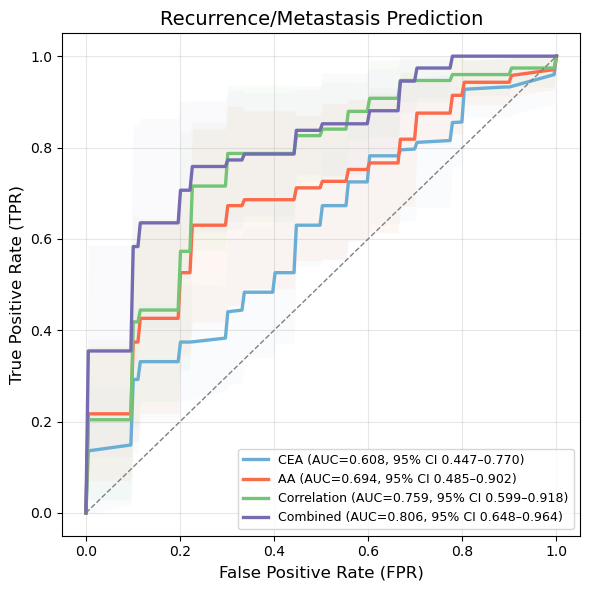

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from joblib import load
import json

# -----------------------------------------------------------
# 1) Load meta info
# -----------------------------------------------------------
meta_df = pd.read_csv("artifacts_0.80/meta/model_meta_per_fold.csv")

feature_sets = {
    "CEA":         X_CEA,
    "AA":          X_AA,
    "Correlation": X_corr,
    "Combined":    X_combined,
}

labels_to_plot = ["CEA", "AA", "Correlation", "Combined"]

base_fpr = np.linspace(0, 1, 200)

plt.figure(figsize=(6, 6))


colors = {
    "CEA":         ("#6aaed6", "#cfe1f2"),   
    "AA":          ("#fb6a4a", "#fcbba1"),   
    "Correlation": ("#74c476", "#c7e9c0"),   
    "Combined":    ("#756bb1", "#dadaeb"),   
}

# -----------------------------------------------------------
# 2) Loop each model
# -----------------------------------------------------------
for label in labels_to_plot:
    
    sub = meta_df[meta_df["feature_set"] == label]
    X = feature_sets[label]

    tprs = []
    aucs = []

    for _, row in sub.iterrows():

        model_path = row["model_path"]
        cols_sel   = row["selected_feats"].split(",")
        test_index = json.loads(row["test_index"])

        clf = load(model_path)

        X_te = X.loc[test_index, cols_sel]
        y_te = y.loc[test_index]

        prob = clf.predict_proba(X_te)[:, 1]
        auc  = roc_auc_score(y_te, prob)
        aucs.append(auc)

        fpr, tpr, _ = roc_curve(y_te, prob)
        tpr_interp = np.interp(base_fpr, fpr, tpr)
        tpr_interp[0] = 0.0
        tprs.append(tpr_interp)

    # mean & std
    mean_tpr = np.mean(tprs, axis=0)
    std_tpr  = np.std(tprs, axis=0)
    mean_tpr[-1] = 1.0

    mean_auc = np.mean(aucs)
    std_auc  = np.std(aucs)

    # 95% CI 
    ci_low   = mean_auc - 1.96 * std_auc
    ci_high  = mean_auc + 1.96 * std_auc

    color_line, color_fill = colors[label]

    # CI band
    plt.fill_between(
        base_fpr,
        np.clip(mean_tpr - std_tpr, 0, 1),
        np.clip(mean_tpr + std_tpr, 0, 1),
        color=color_fill,
        alpha=0.12,
        linewidth=0,
    )

    # mean curve
    plt.plot(
        base_fpr, mean_tpr,
        color=color_line, lw=2.4,
        label=f"{label} (AUC={mean_auc:.3f}, 95% CI {ci_low:.3f}–{ci_high:.3f})",
    )

# -----------------------------------------------------------
# 3) Plot format
# -----------------------------------------------------------
plt.plot([0, 1], [0, 1], "--", color="gray", lw=1)

plt.xlabel("False Positive Rate (FPR)", fontsize=12)
plt.ylabel("True Positive Rate (TPR)", fontsize=12)
plt.title("Recurrence/Metastasis Prediction", fontsize=14)
plt.legend(fontsize=9, loc="lower right")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("figures/ROC_all_models_with_CI.pdf", dpi=300)
plt.show()
